# Bibliotecas

In [7]:
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import pandas as pd
from utils import load_json, save_json

# Tentar usa GPU

Para fazer a configuração do tensorflow com a GPU recomendo fortemente esse vídeo:
https://www.youtube.com/watch?v=ryFFCyhTgyA&t=3s

In [8]:
physical_devices = tf.config.list_physical_devices('GPU')

In [9]:
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU is available and configured.")
    except RuntimeError as e:
        print(e)
else:
    print("GPU is not available, using CPU instead.")

print("ok")

GPU is available and configured.
ok


# Calculando Métricas

# Resnet 50

In [4]:
# Carregar o modelo salvo
model_save_path = r"..\pesquisaDasMangas\modelo_resnet50_classificadorFolhaDeManga.keras"
from tensorflow.keras.models import load_model
resnet50_model = load_model(model_save_path)
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [5]:
resnet50_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

## Generator resnet 50

In [6]:
datagen_resnet50 = tf.keras.preprocessing.image.ImageDataGenerator()

## Evaluate Clean Error

In [7]:
CLEAN_VALIDATION_DATASET_PATH = r"..\imagensLimpasMangoLeaf"
clean_validation_dataset_generator_resnet50 = datagen_resnet50.flow_from_directory(
    CLEAN_VALIDATION_DATASET_PATH,
    target_size=(224, 224),
    batch_size=128,
    shuffle=False
)

Found 4000 images belonging to 8 classes.


## Resnet50 predict

In [8]:
preds = resnet50_model.predict(clean_validation_dataset_generator_resnet50)
predicted_classes = np.argmax(preds, axis=1)

accuracy = accuracy_score(clean_validation_dataset_generator_resnet50.labels, predicted_classes)

32/32 [==============================] - 14s 307ms/step


In [9]:
accuracy

0.711

In [10]:
1 - accuracy

0.28900000000000003

## Image Data Loading

In [11]:
images = keras.utils.image_dataset_from_directory(CLEAN_VALIDATION_DATASET_PATH, batch_size=128, image_size=(224, 224), shuffle=False, crop_to_aspect_ratio=True, interpolation='bicubic')

Found 4000 files belonging to 8 classes.


In [12]:
images

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [13]:
true_class_names = tf.concat([label for _, label in images], axis = 0)

In [14]:
preds = resnet50_model.predict(images)

predicted_classes = np.argmax(preds, axis=1)
accuracy = accuracy_score(true_class_names, predicted_classes)

32/32 [==============================] - 10s 299ms/step


In [15]:
accuracy

0.695

## Evaluate Corruption Error

In [16]:
CORRUPTION_TYPES = {
    'blur': ['defocus_blur', 'gaussian_blur', 'glass_blur', 'motion_blur', 'zoom_blur'],
    'digital': ['contrast', 'elastic_transform', 'jpeg_compression', 'pixelate', 'saturate'],
    'noise': ['gaussian_noise', 'impulse_noise', 'shot_noise', 'speckle_noise'],
    'weather': ['brightness', 'fog', 'frost', 'snow', 'spatter']
}

#Aqui na variável "BASE_PATH" TEM QUE COLOCAR O O CAMINHO DA ESTRUTURA DO BANCO ACEITA PELO PIPELINE. 
#QUE É FEITA PELO CÓDIGO: esseCodigoFoiCriadoParaCriarANovaEstruturaDePastasParaCalcularOMceEORelative.pý
#Caaminho dele e as instruções estão nos comentários dentro dele.
#caminho: ../../scripts/esseCodigoFoiCriadoParaCriarANovaEstruturaDePastasParaCalcularOMceEORelative.py

# Colocar o caminho que você criou a nova estrutura do banco
BASE_PATH = r"../estruturaParaMceERelative_VALIDADO"

## Generator Example

In [17]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

In [18]:
blur_generator_one = datagen.flow_from_directory(
    f'{BASE_PATH}/blur/{CORRUPTION_TYPES["blur"][0]}/1',
    target_size=(224, 224),
    batch_size=64,
    shuffle=False
)

Found 4000 images belonging to 8 classes.


In [19]:
preds = resnet50_model.predict(blur_generator_one)

63/63 [==============================] - 11s 155ms/step


In [20]:
predicted_classes = np.argmax(preds, axis=1)

In [21]:
accuracy = accuracy_score(blur_generator_one.labels, predicted_classes)

In [22]:
1 - accuracy

0.41974999999999996

## Generate Corruption Error for all type of corruptions in Resnet 50

In [5]:
from utils import load_json, save_json

In [24]:
result = {
    'blur': {},
    'digital': {},
    'noise': {},
    'weather': {}
}
for subject in CORRUPTION_TYPES.keys():
    for corruption_type in range(len(CORRUPTION_TYPES[subject])):
        for severity in range(1, 6):
            corruption_name = CORRUPTION_TYPES[subject][corruption_type]

            generator = datagen.flow_from_directory(
                f'{BASE_PATH}/{subject}/{corruption_name}/{severity}',
                target_size=(224, 224),
                batch_size=64,
                shuffle=False
            )

            preds = resnet50_model.predict(generator)
            predicted_classes = np.argmax(preds, axis=1)

            accuracy = accuracy_score(generator.labels, predicted_classes)

            if corruption_name not in result[subject]:
                result[subject][corruption_name] = {}

            result[subject][corruption_name][severity] = 1 - accuracy

            save_json('corruption_resnet50_error.json', result)


Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 161ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 163ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 158ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 159ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 157ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 158ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 158ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 10s 159ms/step
File save with success!
Found 4000 images belong

# Resnet 101

In [25]:
# Carregar o modelo salvo
model_save_path = r"..\pesquisaDasMangas\modelo_resnet101_classificadorFolhaDeManga.keras"
from tensorflow.keras.models import load_model
resnet101_model = load_model(model_save_path)
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [26]:
resnet101_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

## Generator resnet 101

In [27]:
datagen_resnet101 = tf.keras.preprocessing.image.ImageDataGenerator()

## Evaluate Clean Error

In [28]:
CLEAN_VALIDATION_DATASET_PATH = r"..\imagensLimpasMangoLeaf"
clean_validation_dataset_generator_resnet101 = datagen_resnet101.flow_from_directory(
    CLEAN_VALIDATION_DATASET_PATH,
    target_size=(224, 224),
    batch_size=128,
    shuffle=False
)

Found 4000 images belonging to 8 classes.


## Resnet101 predict

In [29]:
preds = resnet101_model.predict(clean_validation_dataset_generator_resnet101)
predicted_classes = np.argmax(preds, axis=1)

accuracy = accuracy_score(clean_validation_dataset_generator_resnet101.labels, predicted_classes)

32/32 [==============================] - 16s 487ms/step


In [30]:
accuracy

0.681

In [31]:
1 - accuracy

0.31899999999999995

## Generate Corruption Error for all type of corruptions in Resnet 101

In [32]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

In [33]:
from utils import load_json, save_json

In [34]:
result = {
    'blur': {},
    'digital': {},
    'noise': {},
    'weather': {}
}
for subject in CORRUPTION_TYPES.keys():
    for corruption_type in range(len(CORRUPTION_TYPES[subject])):
        for severity in range(1, 6):
            corruption_name = CORRUPTION_TYPES[subject][corruption_type]

            generator = datagen.flow_from_directory(
                f'{BASE_PATH}/{subject}/{corruption_name}/{severity}',
                target_size=(224, 224),
                batch_size=64,
                shuffle=False
            )

            preds = resnet101_model.predict(generator)
            predicted_classes = np.argmax(preds, axis=1)

            accuracy = accuracy_score(generator.labels, predicted_classes)

            if corruption_name not in result[subject]:
                result[subject][corruption_name] = {}

            result[subject][corruption_name][severity] = 1 - accuracy

            save_json('corruption_resnet101_error.json', result)


Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 262ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 257ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 256ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 249ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 250ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 249ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 250ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 16s 250ms/step
File save with success!
Found 4000 images belong

# VGG16

In [35]:
# Carregar o modelo salvo
model_save_path = r"..\pesquisaDasMangas\modelo_vgg16_classificadorFolhaDeManga.keras"
from tensorflow.keras.models import load_model
vgg16_model = load_model(model_save_path)
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [36]:
vgg16_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 32)                802848    
                                                                 
 dense_1 (Dense)             (None, 8)                 264       
                                                                 
Total params: 15,517,800
Trainable params: 803,112
Non-trainable params: 14,714,688
_________________________________________________________________


## Generator VGG16

In [37]:
datagen_vgg16 = tf.keras.preprocessing.image.ImageDataGenerator()

## Evaluate Clean Error

In [38]:
CLEAN_VALIDATION_DATASET_PATH = r"..\imagensLimpasMangoLeaf"
clean_validation_dataset_generator_vgg16 = datagen_vgg16.flow_from_directory(
    CLEAN_VALIDATION_DATASET_PATH,
    target_size=(224, 224),
    batch_size=128,
    shuffle=False
)

Found 4000 images belonging to 8 classes.


## VGG16 predict

In [39]:
preds = vgg16_model.predict(clean_validation_dataset_generator_vgg16)
predicted_classes = np.argmax(preds, axis=1)

accuracy = accuracy_score(clean_validation_dataset_generator_vgg16.labels, predicted_classes)

32/32 [==============================] - 29s 460ms/step


In [40]:
accuracy

0.9935

In [41]:
1 - accuracy

0.00649999999999995

## Generate Corruption Error for all type of corruptions in VGG16

In [42]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

In [43]:
from utils import load_json, save_json

In [44]:
result = {
    'blur': {},
    'digital': {},
    'noise': {},
    'weather': {}
}
for subject in CORRUPTION_TYPES.keys():
    for corruption_type in range(len(CORRUPTION_TYPES[subject])):
        for severity in range(1, 6):
            corruption_name = CORRUPTION_TYPES[subject][corruption_type]

            generator = datagen.flow_from_directory(
                f'{BASE_PATH}/{subject}/{corruption_name}/{severity}',
                target_size=(224, 224),
                batch_size=64,
                shuffle=False
            )

            preds = vgg16_model.predict(generator)
            predicted_classes = np.argmax(preds, axis=1)

            accuracy = accuracy_score(generator.labels, predicted_classes)

            if corruption_name not in result[subject]:
                result[subject][corruption_name] = {}

            result[subject][corruption_name][severity] = 1 - accuracy

            save_json('corruption_vgg16_error.json', result)

Found 4000 images belonging to 8 classes.
63/63 [==============================] - 19s 173ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 172ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 173ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 173ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 173ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 173ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 174ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 173ms/step
File save with success!
Found 4000 images belong

# LCNN

In [45]:
# Carregar o modelo salvo
model_save_path = r"..\pesquisaDasMangas\modelo_lcnn_classificadorFolhaDeManga.keras"
from tensorflow.keras.models import load_model
lcnn_model = load_model(model_save_path)
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [46]:
lcnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 64)       0

## Generator LCNN

In [47]:
datagen_lcnn = tf.keras.preprocessing.image.ImageDataGenerator()

## Evaluate Clean Error

In [48]:
CLEAN_VALIDATION_DATASET_PATH = r"..\imagensLimpasMangoLeaf"
clean_validation_dataset_generator_lcnn = datagen_lcnn.flow_from_directory(
    CLEAN_VALIDATION_DATASET_PATH,
    target_size=(224, 224),
    batch_size=128,
    shuffle=False
)

Found 4000 images belonging to 8 classes.


## LCNN predict

In [49]:
preds = lcnn_model.predict(clean_validation_dataset_generator_lcnn)
predicted_classes = np.argmax(preds, axis=1)

accuracy = accuracy_score(clean_validation_dataset_generator_lcnn.labels, predicted_classes)

32/32 [==============================] - 6s 136ms/step


In [50]:
accuracy

0.995

In [51]:
1 - accuracy

0.0050000000000000044

## Generate Corruption Error for all type of corruptions in LCNN

In [52]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

In [53]:
from utils import load_json, save_json

In [54]:
result = {
    'blur': {},
    'digital': {},
    'noise': {},
    'weather': {}
}
for subject in CORRUPTION_TYPES.keys():
    for corruption_type in range(len(CORRUPTION_TYPES[subject])):
        for severity in range(1, 6):
            corruption_name = CORRUPTION_TYPES[subject][corruption_type]

            generator = datagen.flow_from_directory(
                f'{BASE_PATH}/{subject}/{corruption_name}/{severity}',
                target_size=(224, 224),
                batch_size=64,
                shuffle=False
            )

            preds = lcnn_model.predict(generator)
            predicted_classes = np.argmax(preds, axis=1)

            accuracy = accuracy_score(generator.labels, predicted_classes)

            if corruption_name not in result[subject]:
                result[subject][corruption_name] = {}

            result[subject][corruption_name][severity] = 1 - accuracy

            save_json('corruption_lcnn_error.json', result)

Found 4000 images belonging to 8 classes.
63/63 [==============================] - 5s 61ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 4s 60ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 4s 59ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 4s 59ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 4s 58ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 4s 61ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 4s 61ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 4s 60ms/step
File save with success!
Found 4000 images belonging to 8 classes

# Xception

In [59]:
# Carregar o modelo salvo
model_save_path = r"..\pesquisaDasMangas\modelo_xception_classificadorFolhaDeManga.keras"
from tensorflow.keras.models import load_model
xception_model = load_model(model_save_path)
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [61]:
xception_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 111, 111, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 111, 111, 32  128        ['block1_conv1[0][0]']           
 ation)                         )                                                             

## Generator Xception

In [62]:
datagen_xception = tf.keras.preprocessing.image.ImageDataGenerator()

## Evaluate Clean Error

In [63]:
CLEAN_VALIDATION_DATASET_PATH = r"..\imagensLimpasMangoLeaf"
clean_validation_dataset_generator_xception = datagen_xception.flow_from_directory(
    CLEAN_VALIDATION_DATASET_PATH,
    target_size=(224, 224),
    batch_size=128,
    shuffle=False
)

Found 4000 images belonging to 8 classes.


## Xception Predict

In [64]:
preds = xception_model.predict(clean_validation_dataset_generator_xception)
predicted_classes = np.argmax(preds, axis=1)

accuracy = accuracy_score(clean_validation_dataset_generator_xception.labels, predicted_classes)

32/32 [==============================] - 14s 344ms/step


In [65]:
accuracy

0.979

In [66]:
1 - accuracy

0.02100000000000002

## Generate Corruption Error for all type of corruptions in Xception

In [67]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

In [68]:
from utils import load_json, save_json

In [69]:
result = {
    'blur': {},
    'digital': {},
    'noise': {},
    'weather': {}
}
for subject in CORRUPTION_TYPES.keys():
    for corruption_type in range(len(CORRUPTION_TYPES[subject])):
        for severity in range(1, 6):
            corruption_name = CORRUPTION_TYPES[subject][corruption_type]

            generator = datagen.flow_from_directory(
                f'{BASE_PATH}/{subject}/{corruption_name}/{severity}',
                target_size=(224, 224),
                batch_size=64,
                shuffle=False
            )

            preds = xception_model.predict(generator)
            predicted_classes = np.argmax(preds, axis=1)

            accuracy = accuracy_score(generator.labels, predicted_classes)

            if corruption_name not in result[subject]:
                result[subject][corruption_name] = {}

            result[subject][corruption_name][severity] = 1 - accuracy

            save_json('corruption_xception_error.json', result)

Found 4000 images belonging to 8 classes.
63/63 [==============================] - 12s 175ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 176ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 176ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 177ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 177ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 177ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 177ms/step
File save with success!
Found 4000 images belonging to 8 classes.
63/63 [==============================] - 11s 177ms/step
File save with success!
Found 4000 images belong

# Evaluate Corruption Error

In [10]:
corruption_error_resnet50 = load_json('corruption_resnet50_error.json')
corruption_error_resnet101 = load_json('corruption_resnet101_error.json')
corruption_error_vgg16 = load_json('corruption_vgg16_error.json')
corruption_error_lcnn = load_json('corruption_lcnn_error.json')
corruption_error_xception = load_json('corruption_xception_error.json')

File loaded with success!
File loaded with success!
File loaded with success!
File loaded with success!
File loaded with success!


In [11]:
def sum_levels(category_data):
    return {key: sum(levels.values()) for key, levels in category_data.items()}

def sum_corruption_error_by_corruption(corruption_error_data):
    return {category: sum_levels(corruption_error_data[category]) for category in corruption_error_data}

In [12]:
sum_corruption_error_resnet50 = sum_corruption_error_by_corruption(corruption_error_resnet50)
sum_corruption_error_resnet101 = sum_corruption_error_by_corruption(corruption_error_resnet101)
sum_corruption_error_vgg16 = sum_corruption_error_by_corruption(corruption_error_vgg16)
sum_corruption_error_lcnn = sum_corruption_error_by_corruption(corruption_error_lcnn)
sum_corruption_error_xception = sum_corruption_error_by_corruption(corruption_error_xception)

In [13]:
sum_corruption_error_resnet101

{'blur': {'defocus_blur': 2.29425,
  'gaussian_blur': 2.1500000000000004,
  'glass_blur': 3.0285,
  'motion_blur': 2.2715,
  'zoom_blur': 2.3045},
 'digital': {'contrast': 3.03425,
  'elastic_transform': 2.26425,
  'jpeg_compression': 2.3325,
  'pixelate': 2.20925,
  'saturate': 2.2110000000000003},
 'noise': {'gaussian_noise': 3.04275,
  'impulse_noise': 3.11825,
  'shot_noise': 3.20925,
  'speckle_noise': 3.02325},
 'weather': {'brightness': 1.8472499999999998,
  'fog': 2.7175000000000002,
  'frost': 2.729,
  'snow': 2.60375,
  'spatter': 2.40575}}

In [14]:
def sum_levels_relative(category_data, baseline_clean_error):
    result = {}
    for key, levels in category_data.items():
        total_sum = 0.
        for corruption_value in levels.values():
            total_sum += corruption_value - baseline_clean_error
        result[key] = total_sum
    return result
def sum_relative_corruption_error(corruption_error_data, baseline_clean_error):
    return {category: sum_levels_relative(corruption_error_data[category], baseline_clean_error) for category in corruption_error_data}

In [15]:
CLEAN_ERROR_RESNET50 = 0.28900000000000003
CLEAN_ERROR_RESNET101 = 0.31899999999999995
CLEAN_ERROR_VGG16 = 0.00649999999999995
CLEAN_ERROR_LCNN = 0.0050000000000000044
CLEAN_ERROR_XCEPTION = 0.02100000000000002

sum_relative_corruption_error_resnet50 =  sum_relative_corruption_error(corruption_error_resnet50, CLEAN_ERROR_RESNET50)
sum_relative_corruption_error_resnet101 =  sum_relative_corruption_error(corruption_error_resnet101, CLEAN_ERROR_RESNET101)
sum_relative_corruption_error_vgg16 =  sum_relative_corruption_error(corruption_error_vgg16, CLEAN_ERROR_VGG16)
sum_relative_corruption_error_lcnn =  sum_relative_corruption_error(corruption_error_lcnn, CLEAN_ERROR_LCNN)
sum_relative_corruption_error_xception =  sum_relative_corruption_error(corruption_error_xception, CLEAN_ERROR_XCEPTION)

In [16]:
def generate_relative_and_corruption_error(sum_ce_model, sum_rel_ce_model, sum_ce_baseline, sum_rel_ce_baseline, nameNet, CLEAN_ERROR):

    CORRUPTION_TYPES = {
        'blur': ['defocus_blur', 'gaussian_blur', 'glass_blur', 'motion_blur', 'zoom_blur'],
        'digital': ['contrast', 'elastic_transform', 'jpeg_compression', 'pixelate', 'saturate'],
        'noise': ['gaussian_noise', 'impulse_noise', 'shot_noise', 'speckle_noise'],
        'weather': ['brightness', 'fog', 'frost', 'snow', 'spatter']
    }
    
    ce_result = {}
    relative_ce_result = {}
    for key, corruptions in CORRUPTION_TYPES.items():
        for corruption in corruptions:
            corruption_error = sum_ce_model[key][corruption] / sum_ce_baseline[key][corruption]
            relative_corruption_error = sum_rel_ce_model[key][corruption] /  sum_rel_ce_baseline[key][corruption]
            ce_result[corruption] = round(corruption_error * 100)
            relative_ce_result[corruption] = round(relative_corruption_error * 100)

    ce_result['mCE'] = round(sum(ce_result.values()) / 19, 1)
    ce_result['Network'] = nameNet
    ce_result['Error'] = CLEAN_ERROR
    relative_ce_result['Rel. mCE'] = round(sum(relative_ce_result.values()) / 19, 1)
    relative_ce_result['Network'] = nameNet
    relative_ce_result['Error'] = CLEAN_ERROR
    return ce_result, relative_ce_result

In [17]:
ce_result_resnet50, relative_ce_result_resnet50 = generate_relative_and_corruption_error(
    sum_corruption_error_resnet50,
    sum_relative_corruption_error_resnet50,
    sum_corruption_error_resnet101,
    sum_relative_corruption_error_resnet101,
    "ResNet-50",
    CLEAN_ERROR_RESNET50
)

ce_result_vgg16, relative_ce_result_vgg16 = generate_relative_and_corruption_error(
    sum_corruption_error_vgg16,
    sum_relative_corruption_error_vgg16,
    sum_corruption_error_resnet101,
    sum_relative_corruption_error_resnet101,
    "VGG-16",
    CLEAN_ERROR_VGG16
)

ce_result_lcnn, relative_ce_result_lcnn = generate_relative_and_corruption_error(
    sum_corruption_error_lcnn,
    sum_relative_corruption_error_lcnn,
    sum_corruption_error_resnet101,
    sum_relative_corruption_error_resnet101,
    "LCNN",
    CLEAN_ERROR_LCNN
)

ce_result_xception, relative_ce_result_xception = generate_relative_and_corruption_error(
    sum_corruption_error_xception,
    sum_relative_corruption_error_xception,
    sum_corruption_error_resnet101,
    sum_relative_corruption_error_resnet101,
    "Xception",
    CLEAN_ERROR_XCEPTION
)

ce_result_resnet101, relative_ce_result_resnet101 = generate_relative_and_corruption_error(
    sum_corruption_error_resnet101,
    sum_relative_corruption_error_resnet101,
    sum_corruption_error_resnet101,
    sum_relative_corruption_error_resnet101,
    "ResNet-101",
    CLEAN_ERROR_RESNET101
    
)

In [18]:
ce_result_resnet101

{'defocus_blur': 100,
 'gaussian_blur': 100,
 'glass_blur': 100,
 'motion_blur': 100,
 'zoom_blur': 100,
 'contrast': 100,
 'elastic_transform': 100,
 'jpeg_compression': 100,
 'pixelate': 100,
 'saturate': 100,
 'gaussian_noise': 100,
 'impulse_noise': 100,
 'shot_noise': 100,
 'speckle_noise': 100,
 'brightness': 100,
 'fog': 100,
 'frost': 100,
 'snow': 100,
 'spatter': 100,
 'mCE': 100.0,
 'Network': 'ResNet-101',
 'Error': 0.31899999999999995}

In [19]:
ce_result_resnet50

{'defocus_blur': 127,
 'gaussian_blur': 124,
 'glass_blur': 100,
 'motion_blur': 115,
 'zoom_blur': 100,
 'contrast': 103,
 'elastic_transform': 94,
 'jpeg_compression': 106,
 'pixelate': 102,
 'saturate': 102,
 'gaussian_noise': 102,
 'impulse_noise': 102,
 'shot_noise': 98,
 'speckle_noise': 97,
 'brightness': 101,
 'fog': 108,
 'frost': 111,
 'snow': 110,
 'spatter': 98,
 'mCE': 105.3,
 'Network': 'ResNet-50',
 'Error': 0.28900000000000003}

In [20]:
ce_result_vgg16

{'defocus_blur': 80,
 'gaussian_blur': 78,
 'glass_blur': 63,
 'motion_blur': 63,
 'zoom_blur': 58,
 'contrast': 66,
 'elastic_transform': 45,
 'jpeg_compression': 44,
 'pixelate': 33,
 'saturate': 21,
 'gaussian_noise': 74,
 'impulse_noise': 82,
 'shot_noise': 80,
 'speckle_noise': 78,
 'brightness': 34,
 'fog': 64,
 'frost': 122,
 'snow': 57,
 'spatter': 63,
 'mCE': 63.4,
 'Network': 'VGG-16',
 'Error': 0.00649999999999995}

In [21]:
ce_result_lcnn

{'defocus_blur': 34,
 'gaussian_blur': 31,
 'glass_blur': 12,
 'motion_blur': 19,
 'zoom_blur': 15,
 'contrast': 116,
 'elastic_transform': 5,
 'jpeg_compression': 6,
 'pixelate': 2,
 'saturate': 112,
 'gaussian_noise': 69,
 'impulse_noise': 71,
 'shot_noise': 63,
 'speckle_noise': 45,
 'brightness': 48,
 'fog': 114,
 'frost': 66,
 'snow': 87,
 'spatter': 15,
 'mCE': 48.9,
 'Network': 'LCNN',
 'Error': 0.0050000000000000044}

In [22]:
ce_result_xception

{'defocus_blur': 76,
 'gaussian_blur': 75,
 'glass_blur': 40,
 'motion_blur': 54,
 'zoom_blur': 40,
 'contrast': 130,
 'elastic_transform': 15,
 'jpeg_compression': 15,
 'pixelate': 19,
 'saturate': 72,
 'gaussian_noise': 140,
 'impulse_noise': 137,
 'shot_noise': 133,
 'speckle_noise': 141,
 'brightness': 124,
 'fog': 147,
 'frost': 142,
 'snow': 145,
 'spatter': 150,
 'mCE': 94.5,
 'Network': 'Xception',
 'Error': 0.02100000000000002}

In [23]:
relative_ce_result_resnet50

{'defocus_blur': 209,
 'gaussian_blur': 218,
 'glass_blur': 110,
 'motion_blur': 173,
 'zoom_blur': 120,
 'contrast': 116,
 'elastic_transform': 103,
 'jpeg_compression': 139,
 'pixelate': 131,
 'saturate': 130,
 'gaussian_noise': 115,
 'impulse_noise': 114,
 'shot_noise': 106,
 'speckle_noise': 103,
 'brightness': 167,
 'fog': 133,
 'frost': 140,
 'snow': 141,
 'spatter': 114,
 'Rel. mCE': 135.9,
 'Network': 'ResNet-50',
 'Error': 0.28900000000000003}

# mCE

In [24]:
import pandas as pd

# Criando o DataFrame inicial
df_mce = pd.DataFrame([ce_result_resnet50])
df_mce = pd.concat([df_mce, pd.DataFrame([ce_result_resnet101, ce_result_vgg16, ce_result_lcnn, ce_result_xception])], ignore_index=True)

# Melhorando a visualização do DataFrame
pd.set_option('display.max_columns', None)  # Exibe todas as colunas
pd.set_option('display.width', 1000)       # Ajusta a largura da exibição
pd.set_option('display.precision', 2)      # Define a precisão decimal

In [25]:
# Definindo a nova ordem das colunas
nova_ordem_colunas = [
    'Network', 'Error', 'mCE', 'gaussian_noise', 'shot_noise', 'impulse_noise', 'speckle_noise', 'defocus_blur', 'glass_blur', 'motion_blur',
    'zoom_blur','gaussian_blur', 'snow', 'frost', 'fog', 'brightness', 'spatter', 'contrast', 'elastic_transform', 'jpeg_compression','pixelate', 
    'saturate']

# Reordenando as colunas
df_mce = df_mce[nova_ordem_colunas]

In [26]:
df_mce

,Network,Error,mCE,gaussian_noise,shot_noise,impulse_noise,speckle_noise,defocus_blur,glass_blur,motion_blur,zoom_blur,gaussian_blur,snow,frost,fog,brightness,spatter,contrast,elastic_transform,jpeg_compression,pixelate,saturate
0,ResNet-50,2.89e-01,105.3,102,98,102,97,127,100,115,100,124,110,111,108,101,98,103,94,106,102,102
1,ResNet-101,3.19e-01,100.0,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
2,VGG-16,6.50e-03,63.4,74,80,82,78,80,63,63,58,78,57,122,64,34,63,66,45,44,33,21
3,LCNN,5.00e-03,48.9,69,63,71,45,34,12,19,15,31,87,66,114,48,15,116,5,6,2,112
4,Xception,2.10e-02,94.5,140,133,137,141,76,40,54,40,75,145,142,147,124,150,130,15,15,19,72


In [27]:
# Renomeando colunas específicas
df_mce = df_mce.rename(columns={'gaussian_noise': 'Gaussian Noise', 'shot_noise': 'Shot Noise', 'impulse_noise': 'Impulse Noise', 
                        'speckle_noise' : 'Speckle Noise', 'defocus_blur': 'Defocus Blur', 'glass_blur': 'Glass Blur',
                       'motion_blur': 'Motion Blur', 'zoom_blur': 'Zoom Blur', 'gaussian_blur': 'Gaussian Blur', 'snow': 'Snow',
                       'frost': 'Frost', 'fog': 'Fog', 'brightness': 'Brightness', 'spatter': 'Spatter', 'contrast': 'Contrast', 
                       'elastic_transform': 'Elastic', 'jpeg_compression': 'JPEG', 'pixelate': 'Pixelate', 'saturate': 'Saturate'})

In [28]:
# Multiplicando a coluna 'Pontuação' por 100
df_mce['Error'] = df_mce['Error'] * 100

In [29]:
df_mce['Error'] = df_mce['Error'].round(1)

In [30]:
# Ordenando de forma decrescente pela coluna 'Error'
df_mce = df_mce.sort_values(by='Error', ascending=False)

In [31]:
df_mce

,Network,Error,mCE,Gaussian Noise,Shot Noise,Impulse Noise,Speckle Noise,Defocus Blur,Glass Blur,Motion Blur,Zoom Blur,Gaussian Blur,Snow,Frost,Fog,Brightness,Spatter,Contrast,Elastic,JPEG,Pixelate,Saturate
1,ResNet-101,31.9,100.0,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
0,ResNet-50,28.9,105.3,102,98,102,97,127,100,115,100,124,110,111,108,101,98,103,94,106,102,102
4,Xception,2.1,94.5,140,133,137,141,76,40,54,40,75,145,142,147,124,150,130,15,15,19,72
2,VGG-16,0.6,63.4,74,80,82,78,80,63,63,58,78,57,122,64,34,63,66,45,44,33,21
3,LCNN,0.5,48.9,69,63,71,45,34,12,19,15,31,87,66,114,48,15,116,5,6,2,112


In [32]:
print(df_mce.to_latex(index=False))  # Remove o índice se não for necessário


\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrr}
\toprule
Network & Error & mCE & Gaussian Noise & Shot Noise & Impulse Noise & Speckle Noise & Defocus Blur & Glass Blur & Motion Blur & Zoom Blur & Gaussian Blur & Snow & Frost & Fog & Brightness & Spatter & Contrast & Elastic & JPEG & Pixelate & Saturate \\
\midrule
ResNet-101 & 31.900000 & 100.000000 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 & 100 \\
ResNet-50 & 28.900000 & 105.300000 & 102 & 98 & 102 & 97 & 127 & 100 & 115 & 100 & 124 & 110 & 111 & 108 & 101 & 98 & 103 & 94 & 106 & 102 & 102 \\
Xception & 2.100000 & 94.500000 & 140 & 133 & 137 & 141 & 76 & 40 & 54 & 40 & 75 & 145 & 142 & 147 & 124 & 150 & 130 & 15 & 15 & 19 & 72 \\
VGG-16 & 0.600000 & 63.400000 & 74 & 80 & 82 & 78 & 80 & 63 & 63 & 58 & 78 & 57 & 122 & 64 & 34 & 63 & 66 & 45 & 44 & 33 & 21 \\
LCNN & 0.500000 & 48.900000 & 69 & 63 & 71 & 45 & 34 & 12 & 19 & 15 & 31 & 87 & 66 & 114 & 48 & 15 & 116 & 5 & 6 & 2 & 11

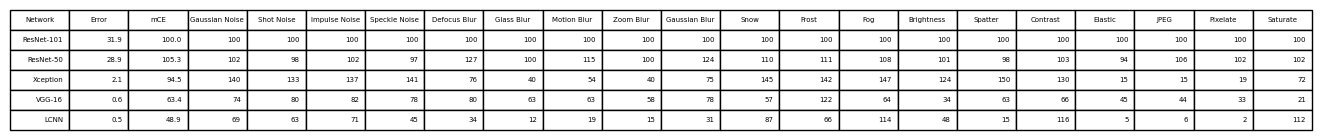

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Criar uma figura e um eixo
fig, ax = plt.subplots(figsize=(8, 0.2))  # Ajuste o tamanho conforme necessário

# Remover os eixos
ax.axis('off')

# Criar a tabela
table = ax.table(cellText=df_mce.values, colLabels=df_mce.columns, loc='center')

# Ajustar o layout
table.auto_set_font_size(False)
table.set_fontsize(5)
table.scale(2.1, 1.2)  # Ajuste a escala conforme necessário

# Salvar a imagem
plt.savefig('tabela_mce.png', bbox_inches='tight', dpi=300)

# Mostrar a imagem (opcional)
plt.show()

# Relative mCE

In [34]:
# Criando o DataFrame inicial
df_relative_mce = pd.DataFrame([relative_ce_result_resnet101])
df_relative_mce = pd.concat([df_relative_mce, pd.DataFrame([relative_ce_result_resnet50, relative_ce_result_vgg16, relative_ce_result_lcnn, relative_ce_result_xception])], ignore_index=True)

In [35]:
# Definindo a nova ordem das colunas
nova_ordem_colunas = [
    'Network', 'Error', 'Rel. mCE', 'gaussian_noise', 'shot_noise', 'impulse_noise', 'speckle_noise', 'defocus_blur', 'glass_blur', 'motion_blur',
    'zoom_blur','gaussian_blur', 'snow', 'frost', 'fog', 'brightness', 'spatter', 'contrast', 'elastic_transform', 'jpeg_compression','pixelate', 
    'saturate']

# Reordenando as colunas
df_relative_mce = df_relative_mce[nova_ordem_colunas]

In [36]:
df_relative_mce

,Network,Error,Rel. mCE,gaussian_noise,shot_noise,impulse_noise,speckle_noise,defocus_blur,glass_blur,motion_blur,zoom_blur,gaussian_blur,snow,frost,fog,brightness,spatter,contrast,elastic_transform,jpeg_compression,pixelate,saturate
0,ResNet-101,3.19e-01,100.0,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
1,ResNet-50,2.89e-01,135.9,115,106,114,103,209,110,173,120,218,141,140,133,167,114,116,103,139,131,130
2,VGG-16,6.50e-03,175.2,154,157,166,162,259,130,207,183,296,144,291,152,237,184,137,148,135,115,72
3,LCNN,5.00e-03,134.7,143,124,145,92,107,24,59,45,115,221,157,275,344,40,243,12,15,2,396
4,Xception,2.10e-02,260.7,287,259,274,292,235,77,165,114,273,365,332,346,870,433,266,36,34,53,242


In [37]:
# Renomeando colunas específicas
df_relative_mce = df_relative_mce.rename(columns={'gaussian_noise': 'Gaussian Noise', 'shot_noise': 'Shot Noise', 'impulse_noise': 'Impulse Noise', 
                        'speckle_noise' : 'Speckle Noise', 'defocus_blur': 'Defocus Blur', 'glass_blur': 'Glass Blur',
                       'motion_blur': 'Motion Blur', 'zoom_blur': 'Zoom Blur', 'gaussian_blur': 'Gaussian Blur', 'snow': 'Snow',
                       'frost': 'Frost', 'fog': 'Fog', 'brightness': 'Brightness', 'spatter': 'Spatter', 'contrast': 'Contrast', 
                       'elastic_transform': 'Elastic', 'jpeg_compression': 'JPEG', 'pixelate': 'Pixelate', 'saturate': 'Saturate'})

In [38]:
# Multiplicando a coluna 'Pontuação' por 100
df_relative_mce['Error'] = df_relative_mce['Error'] * 100

In [39]:
df_relative_mce['Error'] = df_relative_mce['Error'].round(1)

In [40]:
# Ordenando de forma decrescente pela coluna 'Error'
df_relative_mce = df_relative_mce.sort_values(by='Error', ascending=False)

In [41]:
df_relative_mce

,Network,Error,Rel. mCE,Gaussian Noise,Shot Noise,Impulse Noise,Speckle Noise,Defocus Blur,Glass Blur,Motion Blur,Zoom Blur,Gaussian Blur,Snow,Frost,Fog,Brightness,Spatter,Contrast,Elastic,JPEG,Pixelate,Saturate
0,ResNet-101,31.9,100.0,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100
1,ResNet-50,28.9,135.9,115,106,114,103,209,110,173,120,218,141,140,133,167,114,116,103,139,131,130
4,Xception,2.1,260.7,287,259,274,292,235,77,165,114,273,365,332,346,870,433,266,36,34,53,242
2,VGG-16,0.6,175.2,154,157,166,162,259,130,207,183,296,144,291,152,237,184,137,148,135,115,72
3,LCNN,0.5,134.7,143,124,145,92,107,24,59,45,115,221,157,275,344,40,243,12,15,2,396


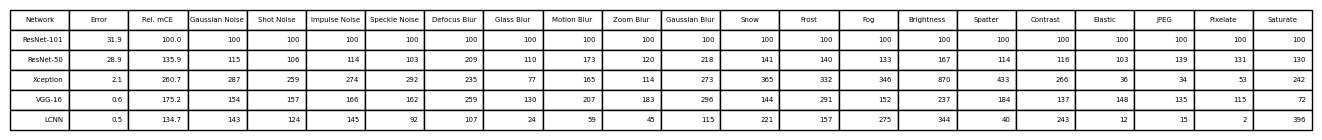

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Criar uma figura e um eixo
fig, ax = plt.subplots(figsize=(8, 0.2))  # Ajuste o tamanho conforme necessário

# Remover os eixos
ax.axis('off')

# Criar a tabela
table = ax.table(cellText=df_relative_mce.values, colLabels=df_relative_mce.columns, loc='center')

# Ajustar o layout
table.auto_set_font_size(False)
table.set_fontsize(5)
table.scale(2.1, 1.2)  # Ajuste a escala conforme necessário

# Salvar a imagem
plt.savefig('tabela_relative_mce.png', bbox_inches='tight', dpi=300)

# Mostrar a imagem (opcional)
plt.show()

In [43]:
import matplotlib.pyplot as plt

# Dados de exemplo (substitua pelos seus)
accuracy = df_mce['Error'].to_numpy()
accuracy = 100 - accuracy
mce = df_mce['mCE'].to_numpy()
relative_mce = df_relative_mce['Rel. mCE'].to_numpy()
labels = df_mce['Network'].to_numpy()

In [44]:
accuracy

array([68.1, 71.1, 97.9, 99.4, 99.5])

In [45]:
mce

array([100. , 105.3,  94.5,  63.4,  48.9])

In [46]:
relative_mce

array([100. , 135.9, 260.7, 175.2, 134.7])

In [47]:
labels

array(['ResNet-101', 'ResNet-50', 'Xception', 'VGG-16', 'LCNN'],
      dtype=object)

# ULTIMA FIGURA DO ARTIGO QUE MOSTRA ACURÁCIA, mCE e Relative mCE no gráfico

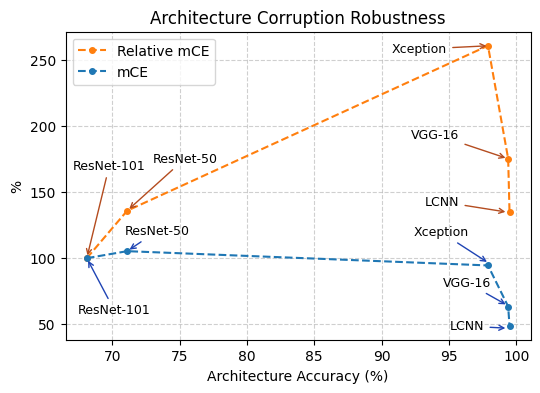

In [290]:
import matplotlib.pyplot as plt
import numpy as np

# Dados de exemplo (substitua pelos seus)
accuracy = df_mce['Error'].to_numpy()
accuracy = 100 - accuracy
mce = df_mce['mCE'].to_numpy()
relative_mce = df_relative_mce['Rel. mCE'].to_numpy()
labels = df_mce['Network'].to_numpy()

# Criando o gráfico
fig, ax = plt.subplots(figsize=(6, 4))

# Plotando com marcadores menores
ax.plot(accuracy, relative_mce, 'o--', color='#ff7f0e', label='Relative mCE', markersize=4)
ax.plot(accuracy, mce, 'o--', color='#1f77b4', label='mCE', markersize=4)

# Adicionar anotações com setas
ax.annotate('ResNet-101', (68.1, 100), textcoords="offset points", xytext=(46,-40), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))
ax.annotate('ResNet-50', (71.1, 105.3), textcoords="offset points", xytext=(45,12), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))
ax.annotate('VGG-16', (99.4, 64), textcoords="offset points", xytext=(-12,14), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))
ax.annotate('LCNN', (99.4, 47), textcoords="offset points", xytext=(-17, -1), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))
ax.annotate('Xception', (98, 96), textcoords="offset points", xytext= (-15,20), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))

# Novas anotações para Relative mCE (laranja)
ax.annotate('ResNet-101', (68.1, 100), textcoords="offset points", xytext=(-10, 64), ha='left', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))
ax.annotate('ResNet-50', (71.1, 135.9), textcoords="offset points", xytext=(65, 35), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))
ax.annotate('VGG-16', (99.4, 175.2), textcoords="offset points", xytext=(-35,15), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))
ax.annotate('LCNN', (99.4, 134.7), textcoords="offset points", xytext=(-35,5), ha='right', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))
ax.annotate('Xception', (98, 260.7), textcoords="offset points", xytext=(-70,-5), ha='left', fontsize=9,
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))

# Formatando o gráfico
ax.set_xlabel("Architecture Accuracy (%)")
ax.set_ylabel("%")
ax.set_title("Architecture Corruption Robustness")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)


# Salvando como PDF vetorial
plt.savefig('architecture_corruption_robustness_MARCADORES_MENORES_SETAS_DUPLAS.pdf', format='pdf', bbox_inches='tight')

# Exibindo o gráfico
plt.show()
